In [1]:
#Importo as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
#Carrego os arquivos de dados
dfVendas = pd.read_csv("dfVendas.csv", delimiter= ",")
dfVendasExtras = pd.read_csv("dfVendasExtras.csv", delimiter= ",")

In [3]:
#Concateno as bases em uma só
dfTotalVendas = pd.concat([dfVendas, dfVendasExtras], ignore_index=True)
dfTotalVendas.head(2)

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha
0,1,350,45,2022-09-23,4,Online,5795.64,17
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16


In [4]:
#Crio uma coluna com o Ano da venda
dfTotalVendas["Ano"] = dfTotalVendas["Data"].str[0:4].astype(int)
dfTotalVendas

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha,Ano
0,1,350,45,2022-09-23,4,Online,5795.64,17,2022
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,2024
2,3,915,75,2022-09-11,4,Online,2057.48,17,2022
3,4,494,47,2024-05-10,4,Loja Física,12864.44,9,2024
4,5,523,79,2023-10-15,4,Loja Física,13317.28,5,2023
...,...,...,...,...,...,...,...,...,...
23995,23996,99,68,2024-11-06,2,Online,9228.82,10,2024
23996,23997,225,90,2024-10-14,2,Loja Física,6536.63,20,2024
23997,23998,974,15,2024-12-29,4,Loja Física,12565.21,6,2024
23998,23999,269,44,2025-06-13,3,Loja Física,9834.99,15,2025


In [5]:
#Somo as vendas por ano
dfVendasAno = dfTotalVendas.groupby("Ano")["Valor_Total"].sum().reset_index()
dfVendasAno

,Ano,Valor_Total
0,2022,54353506.00
1,2023,55018029.76
2,2024,46976758.32
3,2025,19821957.89


In [6]:
#Retiro o ano de 2025, pois não tem a informação de todos os meses
dfVendasAno = dfVendasAno.loc[dfVendasAno["Ano"].isin([2022,2023,2024])]
dfVendasAno

,Ano,Valor_Total
0,2022,54353506.00
1,2023,55018029.76
2,2024,46976758.32


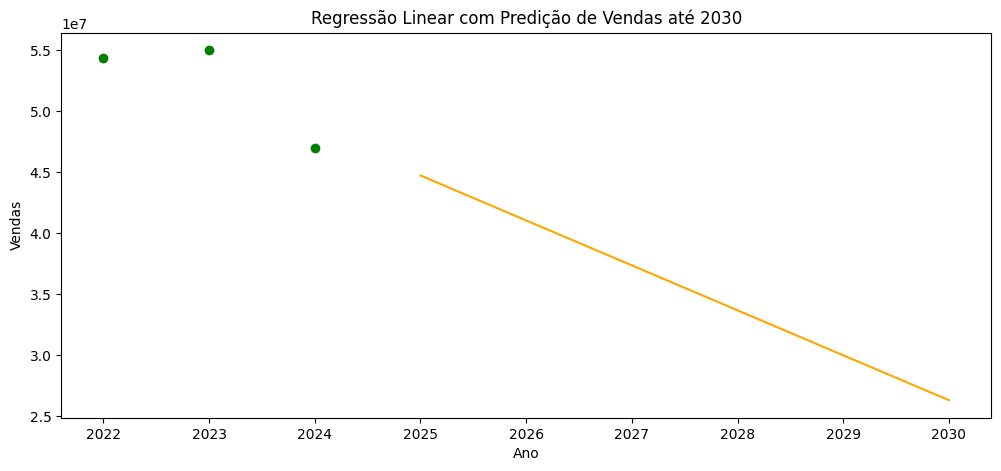

In [7]:
#Defino o x e y do modelo
x = dfVendasAno[["Ano"]]
y = dfVendasAno["Valor_Total"]

#Treinar o modelo
modelo = LinearRegression()
modelo.fit(x,y)

#Fazer a predição para as vendas até 2030
x_predicao = pd.DataFrame({"Ano": [2025, 2026, 2027, 2028, 2029, 2030]})
y_predicao = modelo.predict(x_predicao)

#Visualizar o gráfico
plt.figure(figsize=(12,5))
plt.scatter(dfVendasAno["Ano"], dfVendasAno["Valor_Total"], color='green')
plt.plot(x_predicao["Ano"], y_predicao, color='orange')
plt.xlabel("Ano")
plt.ylabel("Vendas")
plt.title("Regressão Linear com Predição de Vendas até 2030")
plt.show()